sessions: 2565
unique products: 400
avg len: 10.465107212475633
min len: 3
max len: 20


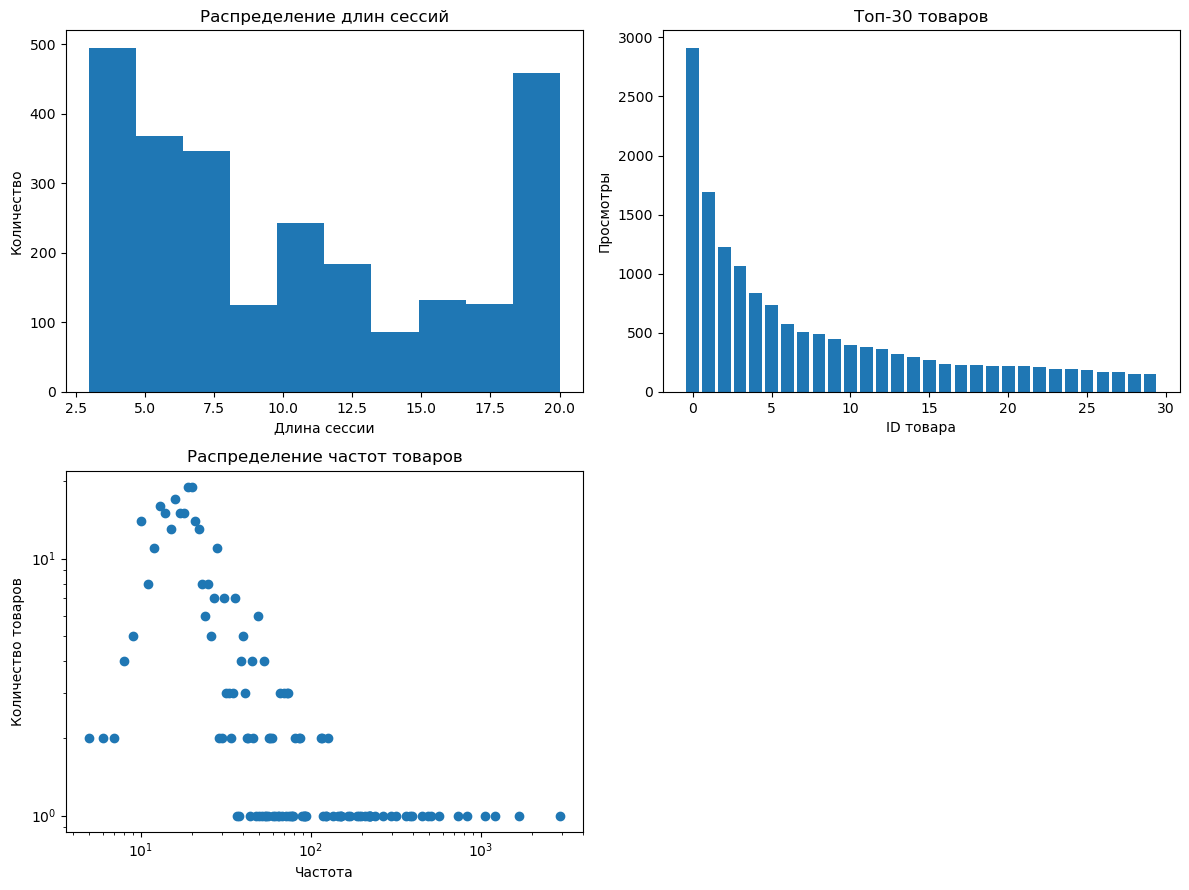

In [14]:
%matplotlib inline

import json, collections, os
import matplotlib.pyplot as plt

# Загрузка

path = "sessions.jsonl"
out = "output"
os.makedirs(out, exist_ok=True)

sess = []
for line in open(path):
    line = line.strip()
    if line:
        sess.append(json.loads(line))

print("sessions:", len(sess))

# Анализ

lens = [len(s) for s in sess]
all_items = [x for s in sess for x in s]
cnt = collections.Counter(all_items)

print("unique products:", len(cnt)) 
print("avg len:", sum(lens)/len(lens))
print("min len:", min(lens))
print("max len:", max(lens))

# Графики

fig, ax = plt.subplots(2,2, figsize=(12,9))

# 1. длины сессий
ax[0,0].hist(lens)
ax[0,0].set_title("Распределение длин сессий")
ax[0,0].set_xlabel("Длина сессии")
ax[0,0].set_ylabel("Количество")

# 2. топ-30 товаров
top30 = cnt.most_common(30)
ax[0,1].bar(range(30), [x[1] for x in top30])
ax[0,1].set_title("Топ-30 товаров")
ax[0,1].set_xlabel("ID товара")
ax[0,1].set_ylabel("Просмотры")

# 3. Распределение частот
freq = collections.Counter(cnt.values())
xs = sorted(freq.keys())
ys = [freq[x] for x in xs]

ax[1,0].scatter(xs, ys)
ax[1,0].set_xscale("log")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Распределение частот товаров")
ax[1,0].set_xlabel("Частота")
ax[1,0].set_ylabel("Количество товаров")

ax[1,1].axis("off")

plt.tight_layout()
plt.show()


In [15]:
import collections

# Train/test split
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:

    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets


train, test = train_test_split(sess)


# Граф переходов

g = collections.defaultdict(collections.Counter)

for s in train:
    for i in range(len(s) - 1):
        g[s[i]][s[i + 1]] += 1

tot = {i: sum(g[i].values()) for i in g}

prob = {
    i: {j: g[i][j] / tot[i] for j in g[i]}
    for i in g
}

print("nodes:", len(g))


# Рекомендации 

train_cnt = collections.Counter(x for s in train for x in s)
popular = [x for x, _ in train_cnt.most_common(50)]


def rec(last, k=10):
    r = []

    if last in prob:
        sorted_items = sorted(
            prob[last].items(),
            key=lambda x: x[1],
            reverse=True
        )

        for item, _ in sorted_items:
            if item != last:
                r.append(item)
            if len(r) == k:
                break

    if len(r) < k:
        for x in popular:
            if x not in r and x != last:
                r.append(x)
            if len(r) == k:
                break

    return r


model = [rec(session[-1]) for session in train]


# Baseline (популярные товары) 

base = []
for session in train:
    last = session[-1]
    recs = []
    for x in popular:
        if x != last:
            recs.append(x)
        if len(recs) == 10:
            break
    base.append(recs)


# Оценка

def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:

    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)


m = hit_at_k(model, test, k=10)
b = hit_at_k(base, test, k=10)

print("model hit@10:", m)
print("baseline hit@10:", b)


nodes: 400
model hit@10: 0.5142300194931774
baseline hit@10: 0.38791423001949316
